# CFTC Managed Money - Net Long: Corn, Wheat (SRW), Soybeans

- **Disaggregated:** the CFTC's weekly Commitments of Traders report, split into four trader
  groups: Producer/Merchant, Swap Dealers, Managed Money, and Other Reportables.
- **Managed Money:** hedge funds and commodity trading advisors, i.e. speculators.
- **Positions:** open futures contracts as of Tuesday, released Friday. **Net long = long − short.**

In [15]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import requests
import yfinance as yf

## 1. Get the data

In [16]:
URL = "https://publicreporting.cftc.gov/resource/72hh-3qpy.json"
MARKETS = {
    "CORN - CHICAGO BOARD OF TRADE": "Corn",
    "WHEAT-SRW - CHICAGO BOARD OF TRADE": "Wheat",
    "SOYBEANS - CHICAGO BOARD OF TRADE": "Soybeans",
}

# Query the CFTC API for the three markets since 2016
names = ", ".join(f"'{m}'" for m in MARKETS)
params = {
    "$where": f"report_date_as_yyyy_mm_dd >= '2016-01-01' AND market_and_exchange_names IN ({names})",
    "$limit": 50000,
}

raw = pd.DataFrame(requests.get(URL, params=params, timeout=60).json())

# Keep managed money long/short and compute net long
df = pd.DataFrame({
    "date": pd.to_datetime(raw["report_date_as_yyyy_mm_dd"]),
    "commodity": raw["market_and_exchange_names"].map(MARKETS),
    "long": raw["m_money_positions_long_all"].astype(int),
    "short": raw["m_money_positions_short_all"].astype(int),
})
df["net_long"] = df["long"] - df["short"]


# Map dates onto a common year so different years overlay on one axis
def to_season(dates):
    dates = pd.DatetimeIndex(dates)
    return pd.to_datetime(dict(year=2000, month=dates.month, day=dates.day)).to_numpy()


df["year"] = df["date"].dt.year
df["season_date"] = to_season(df["date"])
df = df.sort_values("date")

# One column of net long per commodity, indexed by report date
net = df.pivot(index="date", columns="commodity", values="net_long")[list(MARKETS.values())]
net.tail()

commodity,Corn,Wheat,Soybeans
date,,,
2026-09-01,401003,14904,234920
2026-09-08,414459,4873,257258
2026-09-15,414460,-3674,241501
2026-09-22,404097,-12016,265159
2026-09-29,381220,-22109,246558


In [17]:
ETFS = {"Corn": "CORN", "Wheat": "WEAT", "Soybeans": "SOYB"}

# Daily closing prices, with columns renamed from ticker to commodity
etf = yf.download(list(ETFS.values()), start="2016-01-01", auto_adjust=True, progress=False)["Close"]
etf = etf.rename(columns={ticker: commodity for commodity, ticker in ETFS.items()})[list(MARKETS.values())]
etf.tail()

Ticker,Corn,Wheat,Soybeans
Date,,,
2026-10-01,18.980000,24.719999,27.200001
2026-10-02,18.850000,24.750000,27.219999
2026-10-05,18.900000,25.090000,27.320000
2026-10-06,19.290001,25.490000,27.730000
2026-10-07,19.049999,24.900000,27.590000


## 2. Net long in 2026

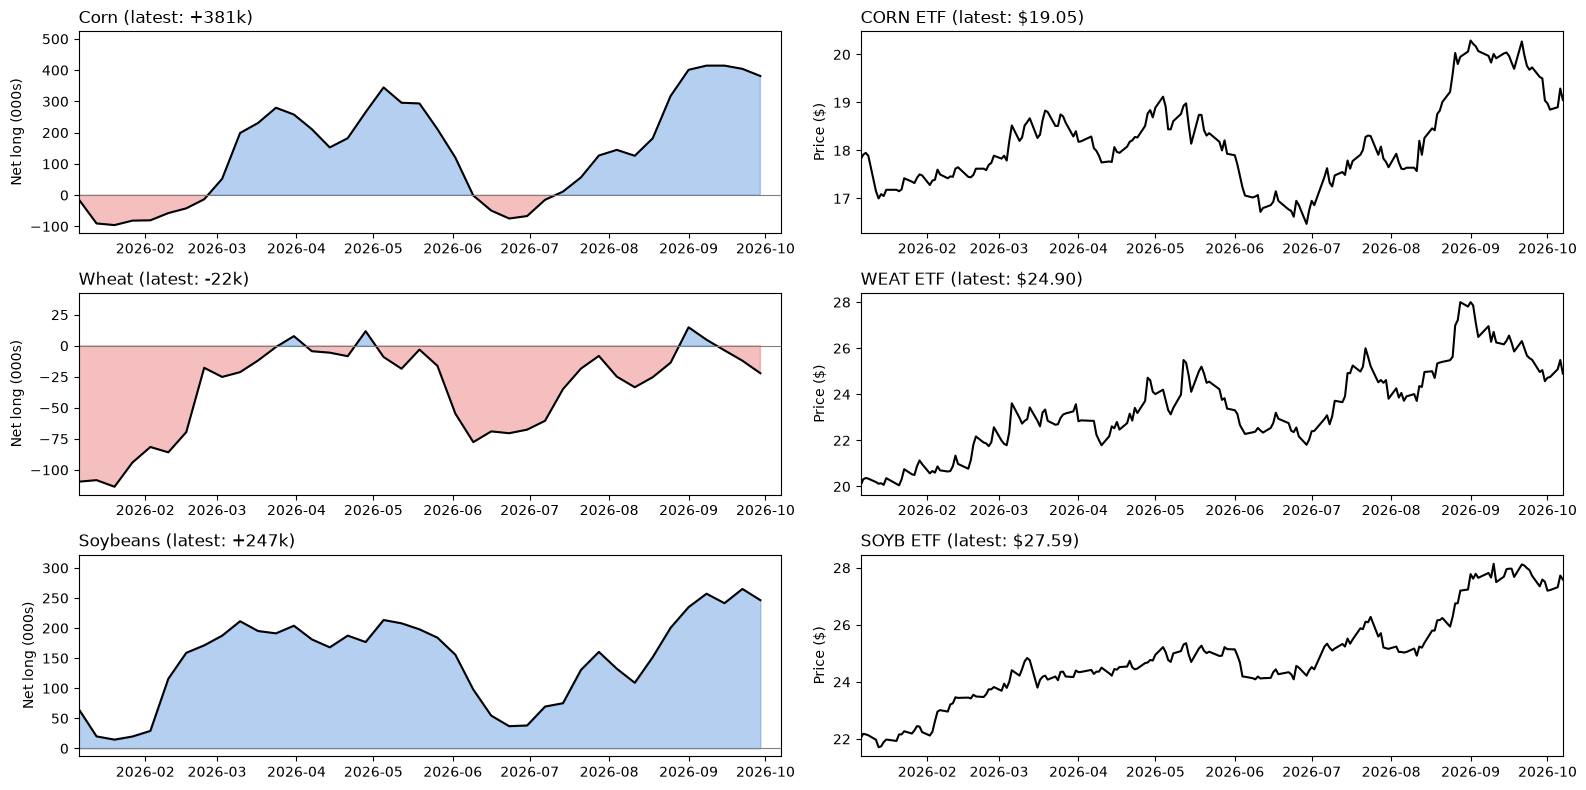

In [22]:
# Grey band of +/- 1 week around each WASDE release, with a line on the release date
def shade_wasde(ax, wasde, end):
    for d in [d for d in wasde if d <= end]:
        ax.axvspan(d - pd.Timedelta(weeks=1), d + pd.Timedelta(weeks=1), color="lightgrey", alpha=0.5)
        ax.axvline(d, color="black", linewidth=1)


# Label the net change from the last report before each WASDE to the first report after it
def annotate_wasde(ax, s, wasde):
    for d in wasde:
        before, after = s.loc[:d - pd.Timedelta(days=1)], s.loc[d:]
        if before.empty or after.empty:
            continue
        t0, t1 = before.index[-1], after.index[0]
        change = s[t1] - s[t0]
        color = "grey" if round(change) == 0 else "#2a78d6" if change > 0 else "#e34948"
        # Thick segment between the two reports, with the change labelled above its midpoint
        ax.plot([t0, t1], [s[t0], s[t1]], color=color, linewidth=4, solid_capstyle="round", zorder=3)
        ax.annotate(f"{change:+,.0f}k", xy=(t0 + (t1 - t0) / 2, (s[t0] + s[t1]) / 2),
                    xytext=(0, 14), textcoords="offset points", ha="center", va="bottom",
                    fontsize=9, fontweight="bold", color=color, zorder=4,
                    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=color))
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax + 0.15 * (ymax - ymin))  # headroom for the labels


# One row per commodity; adds an ETF price column on the right when prices are given
def plot_net(data, prices=None, wasde=(), dots=False, figsize=(10, 8)):
    ncols = 1 if prices is None else 2
    fig, axes = plt.subplots(3, ncols, figsize=figsize, sharex=True, squeeze=False)
    for row, commodity in zip(axes, data.columns):
        # Net long: blue fill when funds are net long, red when net short
        s = data[commodity].dropna()
        ax = row[0]
        shade_wasde(ax, wasde, s.index.max())
        ax.plot(s, color="black", marker="o" if dots else None, markersize=4)
        ax.fill_between(s.index, s, where=s > 0, color="#2a78d6", alpha=0.35, interpolate=True)
        ax.fill_between(s.index, s, where=s < 0, color="#e34948", alpha=0.35, interpolate=True)
        ax.axhline(0, color="grey", linewidth=0.8)
        ax.set_title(f"{commodity} (latest: {s.iloc[-1]:+,.0f}k)", loc="left")
        ax.set_ylabel("Net long (000s)")
        ax.set_xlim(s.index.min(), s.index.max())
        annotate_wasde(ax, s, wasde)
        ax.tick_params(labelbottom=True)

        # ETF price over the same period
        if prices is not None:
            p = prices[commodity].loc[s.index.min():].dropna()
            pax = row[1]
            shade_wasde(pax, wasde, p.index.max())
            pax.plot(p, color="black")
            pax.set_title(f"{ETFS[commodity]} ETF (latest: ${p.iloc[-1]:.2f})", loc="left")
            pax.set_ylabel("Price ($)")
            pax.set_xlim(s.index.min(), max(s.index.max(), p.index.max()))
            pax.tick_params(labelbottom=True)
    fig.tight_layout()
    return fig, axes.squeeze()


# 2026 only, in thousands of contracts
net_2026 = net.loc["2026"] / 1000
plot_net(net_2026, prices=etf, figsize=(16, 8))
plt.show()

## 3. Net long in 2026, with WASDE releases

Each WASDE release is marked with a vertical line. The highlighted segment and label show the change in
net long (000s) from the last weekly report before the release to the first one after it:
blue for funds adding length, red for funds cutting it.

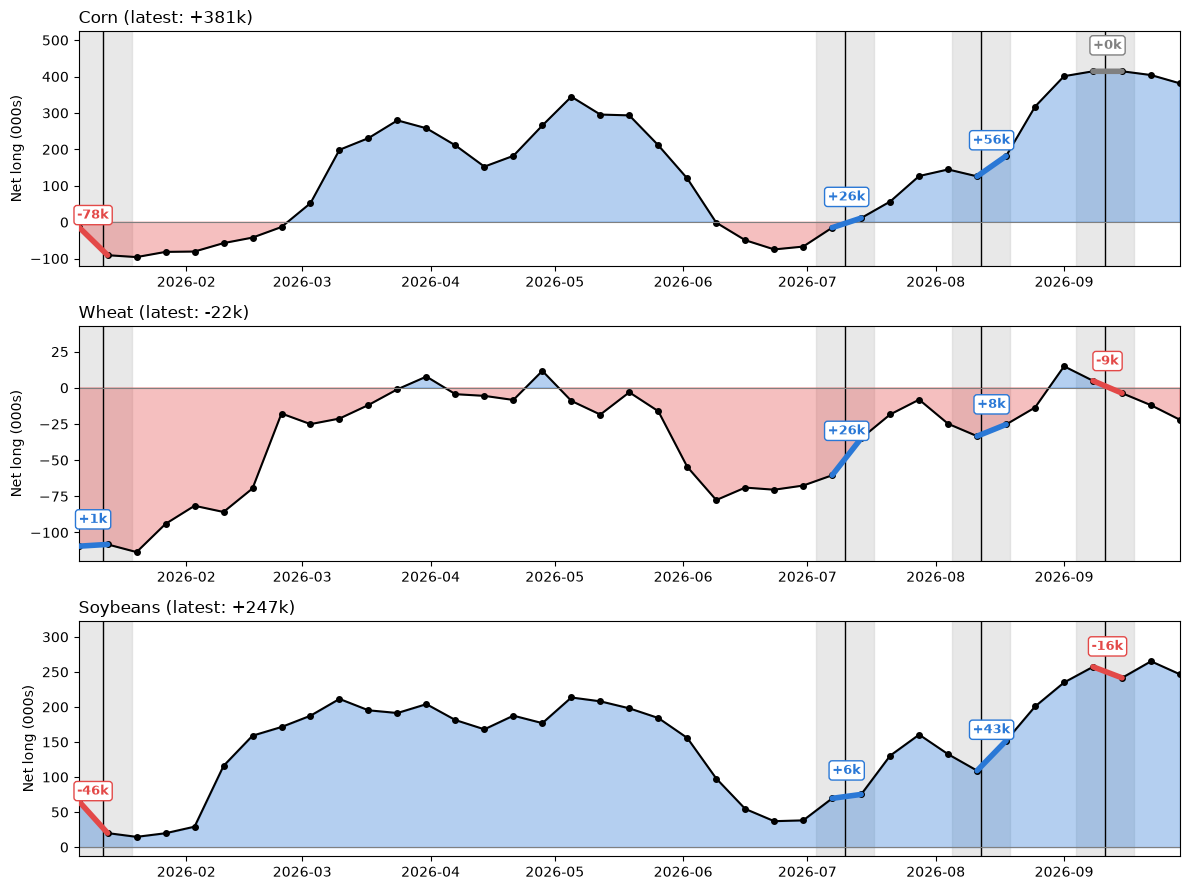

In [19]:
# WASDE release dates in 2026
WASDE = pd.to_datetime(["2026-01-12", "2026-07-10", "2026-08-12", "2026-09-11"])
plot_net(net_2026, wasde=WASDE, dots=True, figsize=(12, 9))
plt.show()

## 4. Seasonality

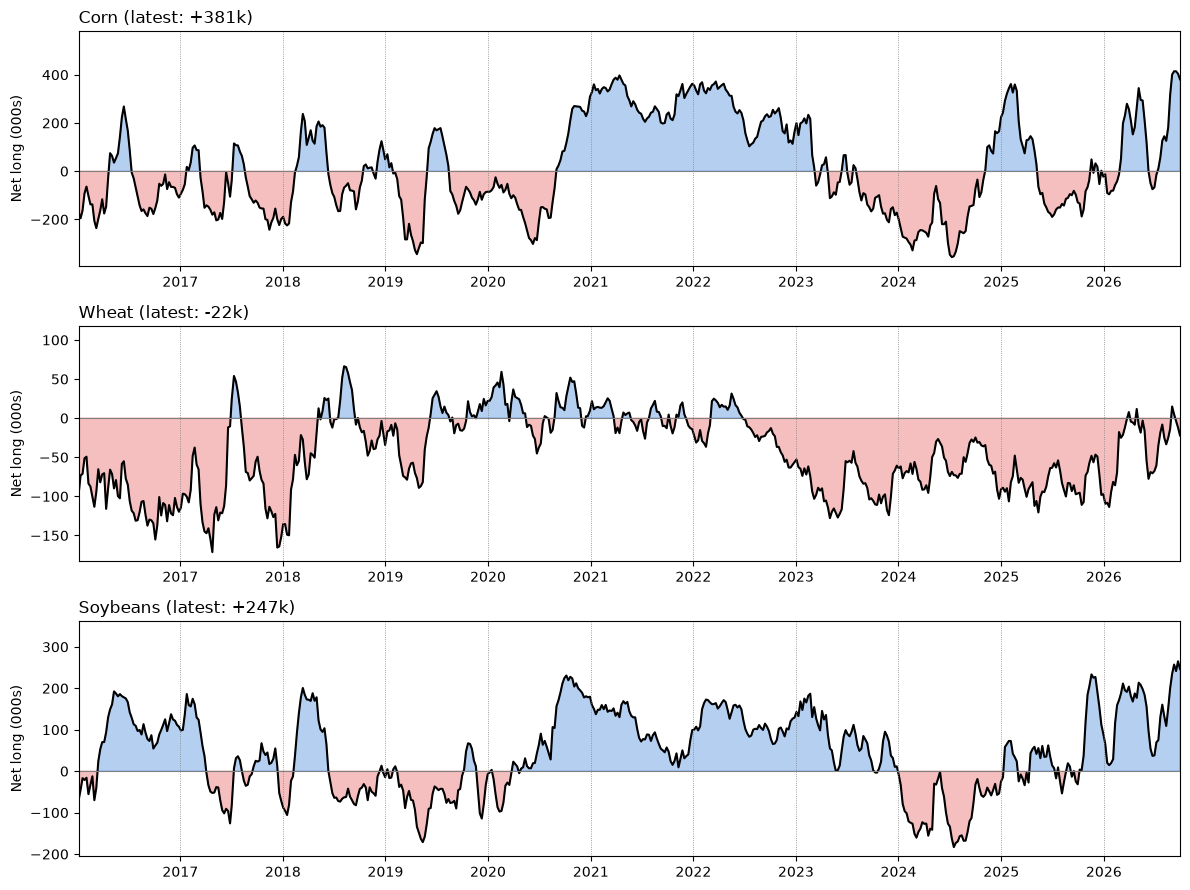

In [20]:
# Full history, with a dotted line at the start of each year
fig, axes = plot_net(net / 1000, figsize=(12, 9))
for ax in axes:
    for year_start in pd.date_range(net.index.min(), net.index.max(), freq="YS"):
        ax.axvline(year_start, color="grey", linewidth=0.6, linestyle=":")
plt.show()


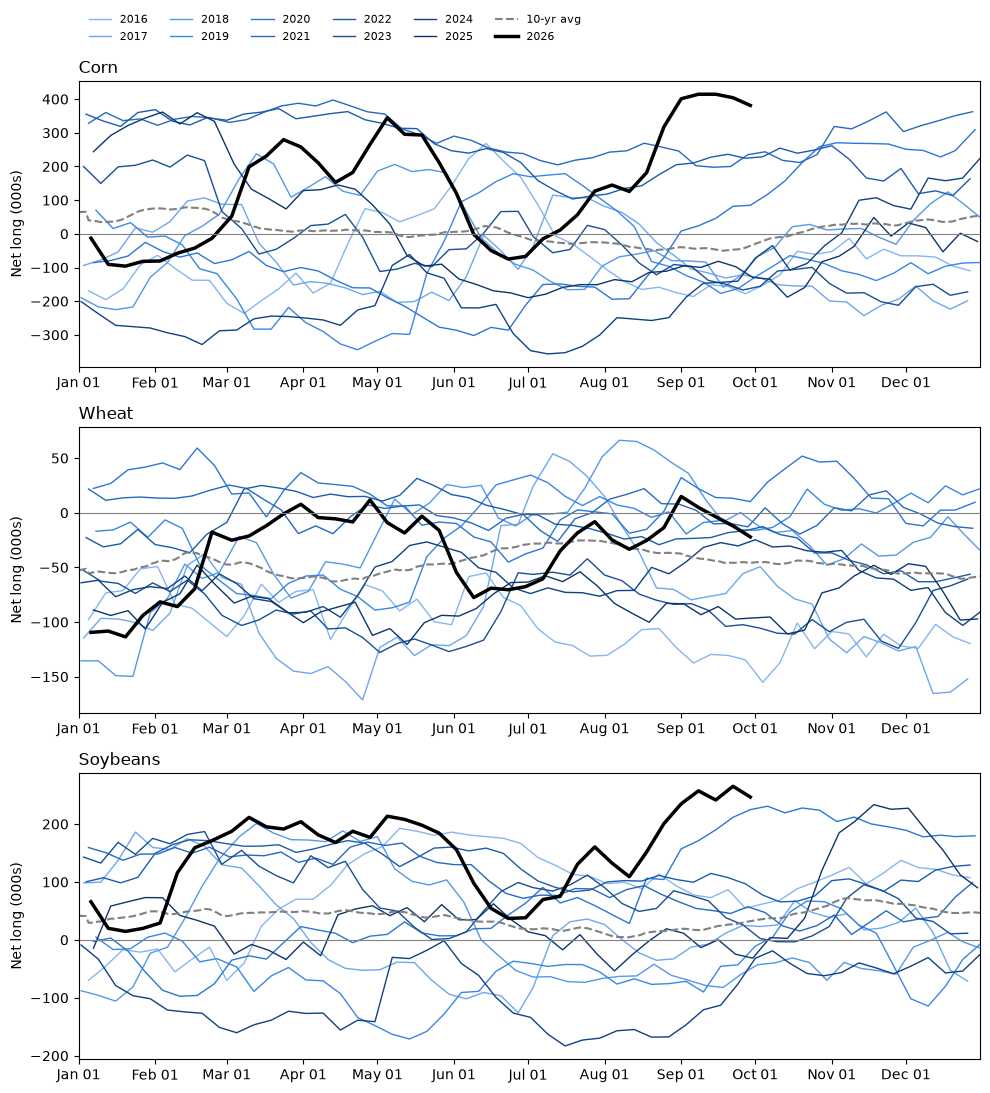

In [ ]:
this_year = df["year"].max()
YEAR_COLORS = ["#86b6ef", "#6da7ec", "#5598e7", "#3987e5", "#2a78d6",
               "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]

fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)
for ax, commodity in zip(axes, MARKETS.values()):
    # Each year's net long on the common seasonal axis
    by_year = {year: g.set_index("season_date")["net_long"] / 1000
               for year, g in df[df["commodity"] == commodity].groupby("year")}
    past = {year: s for year, s in by_year.items() if year != this_year}

    # Past years in lighter blues, oldest lightest
    for (year, s), color in zip(past.items(), YEAR_COLORS):
        ax.plot(s, color=color, linewidth=1, label=year)

    # 10-yr average: interpolate to daily, drop this year and Feb 29, average by calendar day
    daily = net[commodity].resample("D").interpolate() / 1000
    daily = daily[daily.index.year != this_year]
    daily = daily[~((daily.index.month == 2) & (daily.index.day == 29))]
    ax.plot(daily.groupby(to_season(daily.index)).mean(), color="grey", linestyle="--", label="10-yr avg")

    # This year in bold black on top
    ax.plot(by_year[this_year], color="black", linewidth=2.5, label=this_year)
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.set_title(commodity, loc="left")
    ax.set_ylabel("Net long (000s)")
    ax.set_xlim(pd.Timestamp("2000-01-01"), pd.Timestamp("2000-12-31"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.tick_params(labelbottom=True)

axes[0].legend(ncol=6, fontsize=8, loc="lower left", bbox_to_anchor=(0, 1.1), frameon=False)
fig.tight_layout()
plt.show()